# Descriptive Overview

High-level descriptive statistics for the historical task log.

In [1]:
from pathlib import Path
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

ROOT = Path.cwd().resolve()
while not (ROOT / "agents.md").exists():
    if ROOT.parent == ROOT:
        raise RuntimeError("Could not locate project root from notebook directory.")
    ROOT = ROOT.parent

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

warnings.filterwarnings("ignore")
pd.options.display.max_columns = 120
pd.options.display.max_rows = 50

from data_analysis._shared.eda_utils import (
    ENRICHED_PATH,
    FEATURE_GROUPS,
    NUMERIC_OUTLIER_COLUMNS,
    build_enriched_tasks,
    categorical_variants,
    cross_sheet_consistency_report,
    detect_outliers,
    diagnose_client_unmatched,
    diagnose_pair_unmatched,
    diagnose_schedule_unmatched,
    dtype_audit,
    exact_duplicates,
    join_datasets,
    load_all_data,
    load_enriched_tasks,
    missing_summary,
    missingness_by_group,
    missingness_correlation,
    near_duplicates_data,
    proofread_reviewer_comparison,
    same_language_examples,
    same_language_report,
    set_plot_style,
    sheet_dimensions_report,
    summarize_join_integrity,
    timestamp_logic_report,
    timestamp_violation_samples,
    translator_on_time_summary,
    translator_quality_summary,
    wilson_interval,
    zero_value_report,
)

set_plot_style()
sheets = load_all_data()
data = sheets["data"]
schedules = sheets["schedules"]
clients = sheets["clients"]
pairs = sheets["pairs"]
print(f"Loaded Data={data.shape}, Schedules={schedules.shape}, Clients={clients.shape}, Pairs={pairs.shape}")

Loaded Data=(997933, 29), Schedules=(983, 11), Clients=(2645, 6), Pairs=(4688, 7)


In [2]:
overview = pd.DataFrame(
    [
        {"metric": "Total tasks", "value": len(data)},
        {"metric": "Unique projects", "value": data["PROJECT_ID"].nunique()},
        {"metric": "Unique PMs", "value": data["PM"].nunique()},
        {"metric": "Unique translators", "value": data["TRANSLATOR"].nunique()},
        {"metric": "Unique clients", "value": data["MANUFACTURER"].nunique()},
    ]
)
display(overview)

,metric,value
0,Total tasks,997933
1,Unique projects,13692
2,Unique PMs,4
3,Unique translators,983
4,Unique clients,2645


,TASK_TYPE,task_count,proportion_pct
0,ProofReading,430554,43.14
1,Translation,401377,40.22
2,Miscellaneous,83893,8.41
3,PostEditing,67699,6.78
4,Engineering,7710,0.77
5,LanguageLead,3490,0.35
6,Management,1758,0.18
7,DTP,1141,0.11
8,TEST,192,0.02
9,Spotcheck,47,0.0


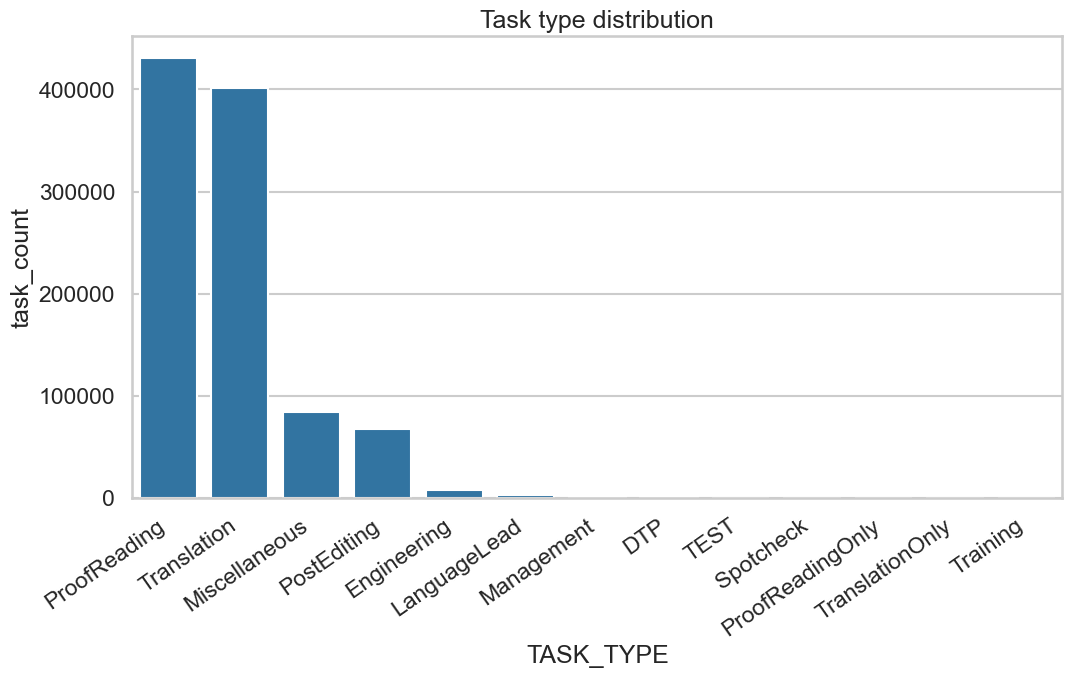

In [3]:
task_type_dist = (
    data["TASK_TYPE_CLEAN"]
    .value_counts(dropna=False)
    .rename_axis("TASK_TYPE")
    .reset_index(name="task_count")
)
task_type_dist["proportion_pct"] = (task_type_dist["task_count"] / len(data) * 100).round(2)
display(task_type_dist)

plt.figure(figsize=(12, 6))
sns.barplot(data=task_type_dist, x="TASK_TYPE", y="task_count", color="#1f77b4")
plt.xticks(rotation=35, ha="right")
plt.title("Task type distribution")
plt.show()

,SOURCE_LANG,count
0,English,965047
1,German,15502
2,Spanish (Iberian),10619
3,Catalan,1739
4,French,1613
5,Spanish (Global),1613
6,Spanish (LA),462
7,Portuguese (Brazil),344
8,Italian,251
9,Dutch,151


,TARGET_LANG,count
0,Spanish (Iberian),486555
1,Galician,136447
2,Catalan,105801
3,Spanish (LA),93528
4,Spanish (Global),36491
5,Basque,34119
6,Portuguese (Brazil),31324
7,Portuguese (Iberian),21920
8,Quechua,9883
9,Guaraní,7030


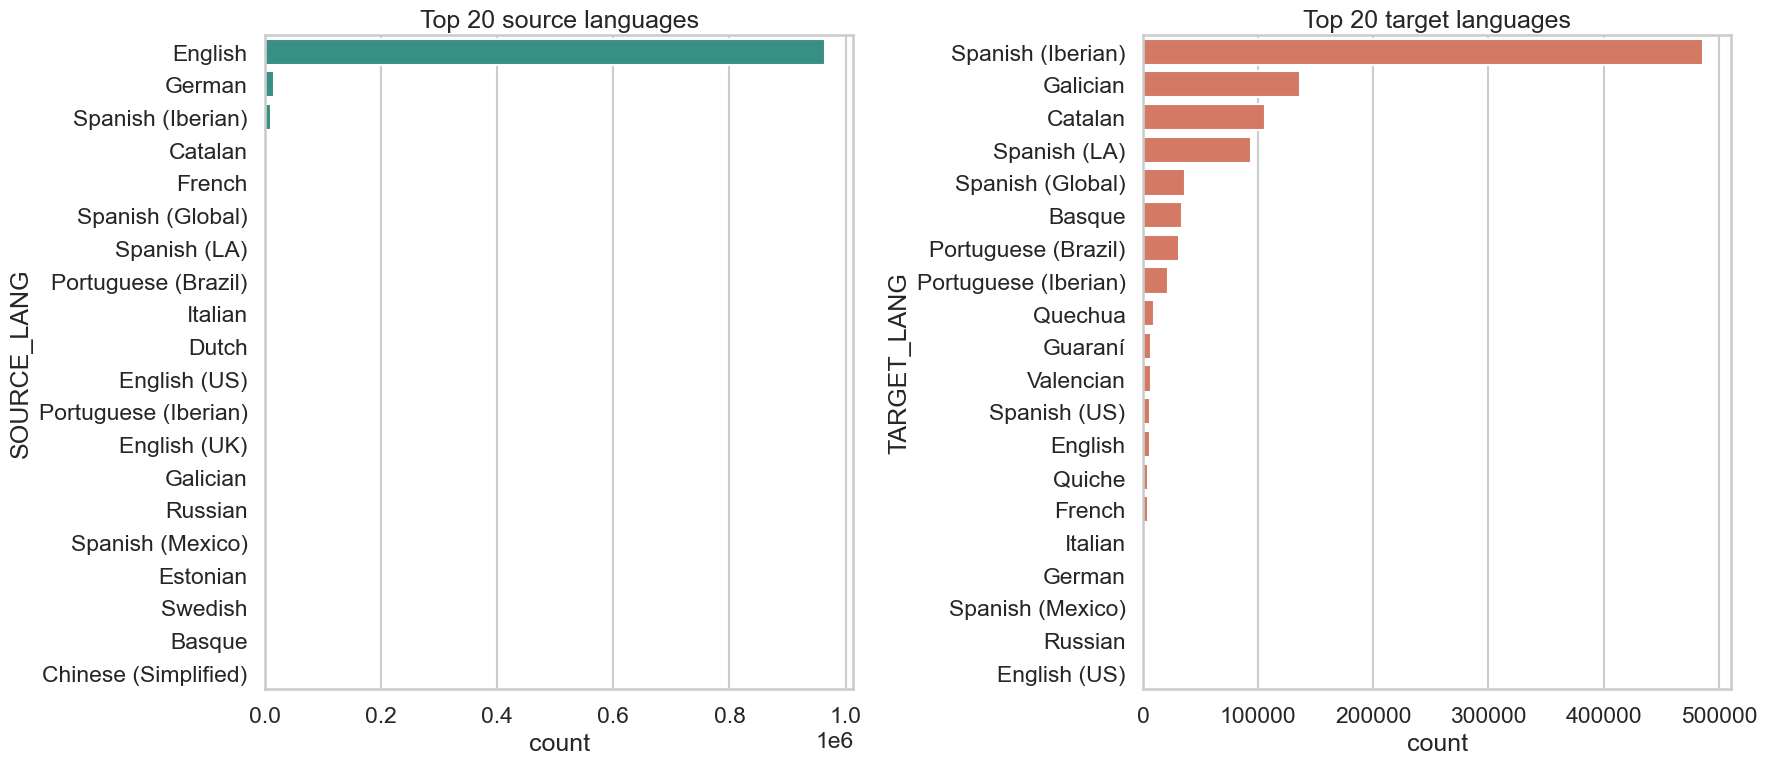

In [4]:
source_dist = data["SOURCE_LANG"].value_counts().rename_axis("SOURCE_LANG").reset_index(name="count")
target_dist = data["TARGET_LANG"].value_counts().rename_axis("TARGET_LANG").reset_index(name="count")
display(source_dist.head(20))
display(target_dist.head(20))

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
sns.barplot(data=source_dist.head(20), x="count", y="SOURCE_LANG", ax=axes[0], color="#2a9d8f")
axes[0].set_title("Top 20 source languages")
sns.barplot(data=target_dist.head(20), x="count", y="TARGET_LANG", ax=axes[1], color="#e76f51")
axes[1].set_title("Top 20 target languages")
plt.tight_layout()
plt.show()

,language_pair,count
0,English -> Spanish (Iberian),471597
1,English -> Galician,136330
2,English -> Catalan,103275
3,English -> Spanish (LA),91952
4,English -> Spanish (Global),35769
5,English -> Basque,33918
6,English -> Portuguese (Brazil),30693
7,English -> Portuguese (Iberian),20360
8,German -> Spanish (Iberian),12450
9,English -> Quechua,9780


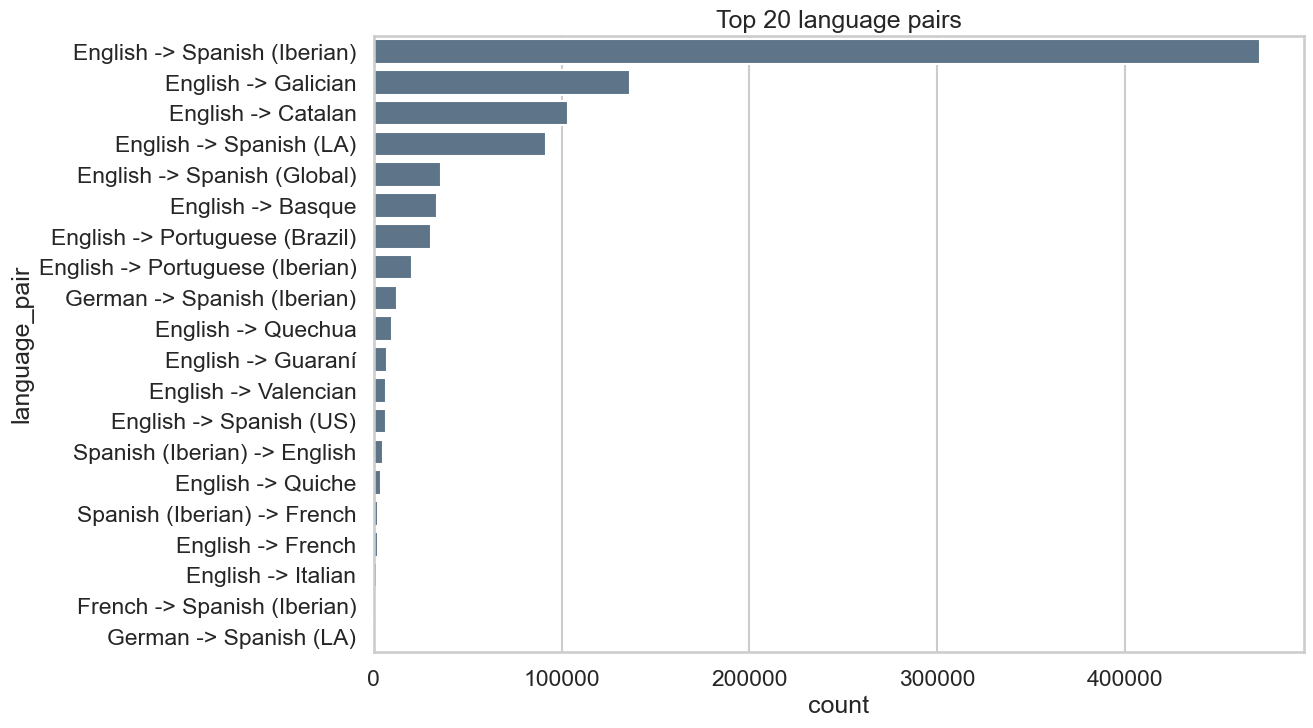

In [5]:
data["LANGUAGE_PAIR"] = data["SOURCE_LANG"] + " -> " + data["TARGET_LANG"]
pair_dist = data["LANGUAGE_PAIR"].value_counts().head(20).rename_axis("language_pair").reset_index(name="count")
display(pair_dist)

plt.figure(figsize=(12, 8))
sns.barplot(data=pair_dist, x="count", y="language_pair", color="#577590")
plt.title("Top 20 language pairs")
plt.show()

,value
count,997933.000000
mean,7.042846
median,7.000000
std,1.463400
min,0.000000
max,10.000000


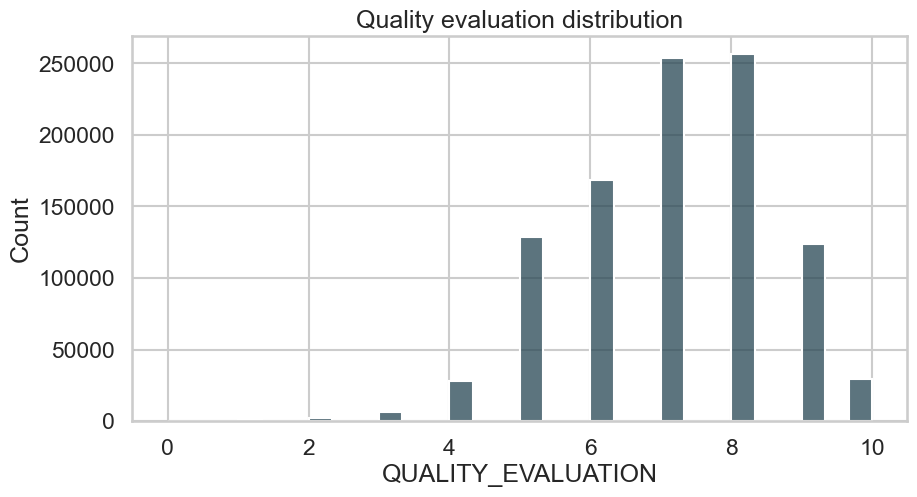

In [6]:
quality_stats = data["QUALITY_EVALUATION"].agg(["count", "mean", "median", "std", "min", "max"]).to_frame("value")
display(quality_stats)

plt.figure(figsize=(10, 5))
sns.histplot(data["QUALITY_EVALUATION"].dropna(), bins=30, color="#264653")
plt.title("Quality evaluation distribution")
plt.show()

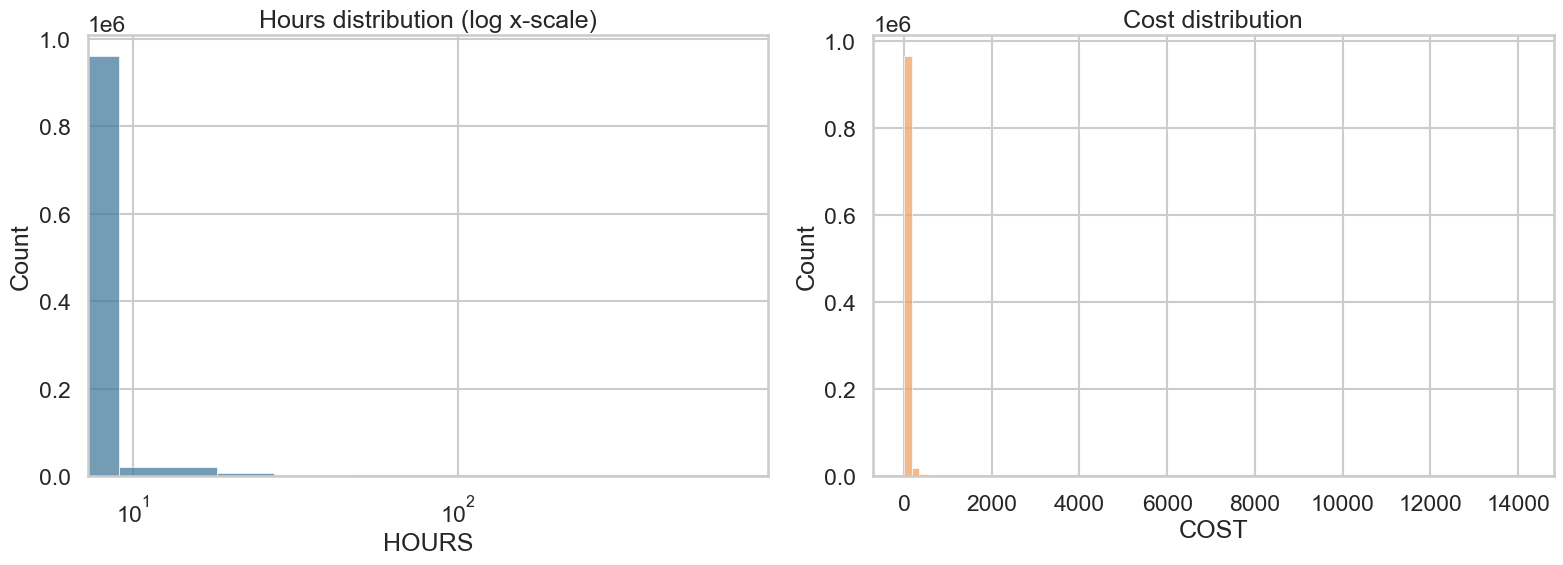

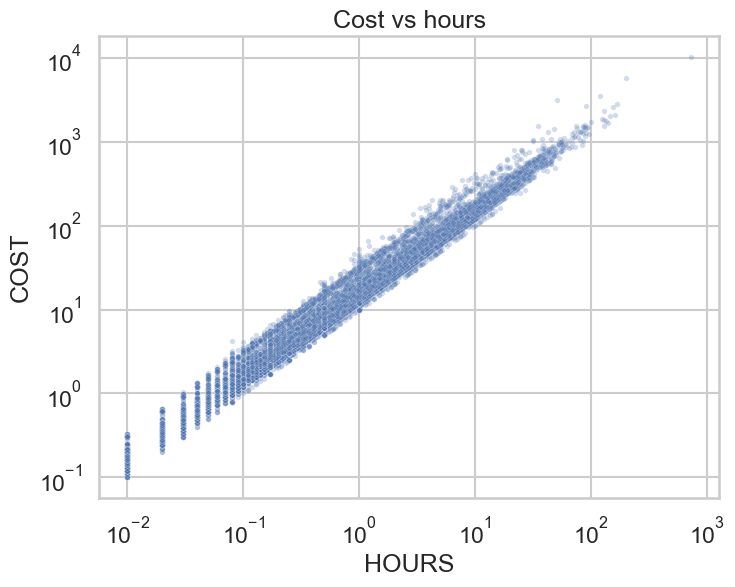

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.histplot(data["HOURS"].dropna(), bins=80, ax=axes[0], color="#457b9d")
axes[0].set_xscale("log")
axes[0].set_title("Hours distribution (log x-scale)")

sns.histplot(data["COST"].dropna(), bins=80, ax=axes[1], color="#f4a261")
axes[1].set_title("Cost distribution")
plt.tight_layout()
plt.show()

cost_hours_sample = data[["HOURS", "COST"]].dropna().sample(30000, random_state=42)
plt.figure(figsize=(8, 6))
sns.scatterplot(data=cost_hours_sample, x="HOURS", y="COST", alpha=0.25, s=15)
plt.xscale("log")
plt.yscale("log")
plt.title("Cost vs hours")
plt.show()

,Data sheet,TranslatorsCost+Pairs sheet
count,997926.000000,4683.000000
mean,17.060431,21.157591
std,4.231651,9.443052
min,8.000000,8.000000
25%,15.000000,15.000000
50%,16.000000,18.000000
75%,18.000000,24.000000
max,62.000000,62.000000


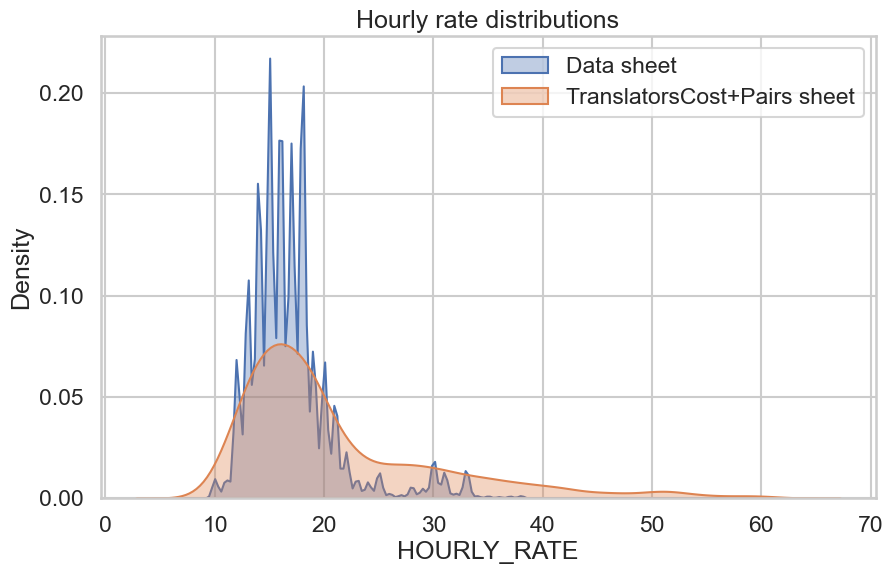

In [8]:
hourly_rate_compare = pd.DataFrame(
    {
        "Data sheet": data["HOURLY_RATE"].dropna(),
        "TranslatorsCost+Pairs sheet": pairs["HOURLY_RATE"].dropna(),
    }
)
display(
    pd.DataFrame(
        {
            "Data sheet": data["HOURLY_RATE"].describe(),
            "TranslatorsCost+Pairs sheet": pairs["HOURLY_RATE"].describe(),
        }
    )
)

plt.figure(figsize=(10, 6))
sns.kdeplot(data["HOURLY_RATE"].dropna(), label="Data sheet", fill=True, alpha=0.35)
sns.kdeplot(pairs["HOURLY_RATE"].dropna(), label="TranslatorsCost+Pairs sheet", fill=True, alpha=0.35)
plt.title("Hourly rate distributions")
plt.legend()
plt.show()

,PM,task_count
0,RMT,384044
1,BMT,252721
2,KMT,185182
3,PMT,175986


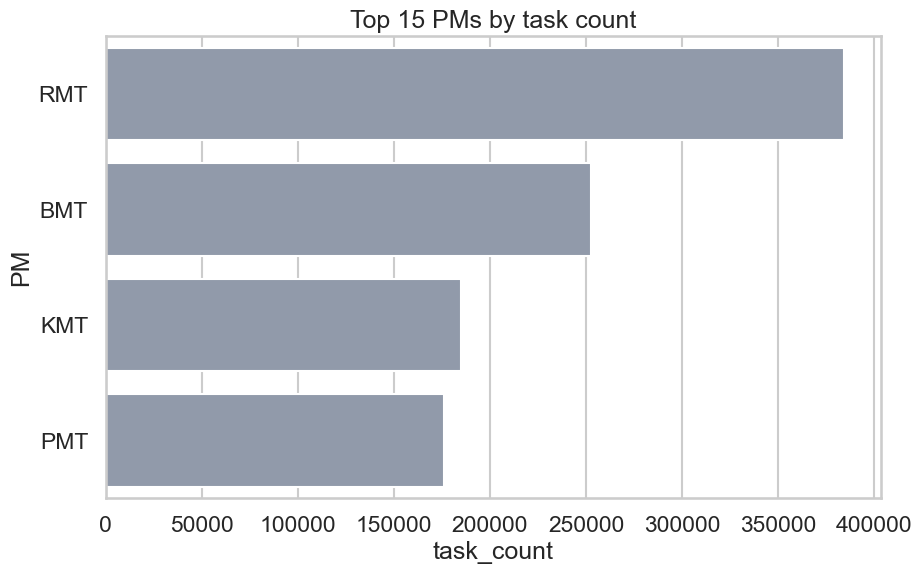

In [9]:
pm_dist = data["PM"].value_counts().rename_axis("PM").reset_index(name="task_count")
display(pm_dist.head(20))

plt.figure(figsize=(10, 6))
sns.barplot(data=pm_dist.head(15), x="task_count", y="PM", color="#8d99ae")
plt.title("Top 15 PMs by task count")
plt.show()

,sector,task_count
0,Information Technology,379310
1,Communication Services,310322
2,Consumer Discretionary & Services,111221
3,Health Care,104450
4,"Industrials, Transportation & Commercial Services",59833
5,Real Estate,15440
6,Financials,5484
7,Consumer Staples & Non-Cyclical Goods,4242
8,Materials & Mining,3535
9,"Public, Education & Non-Profit",1722


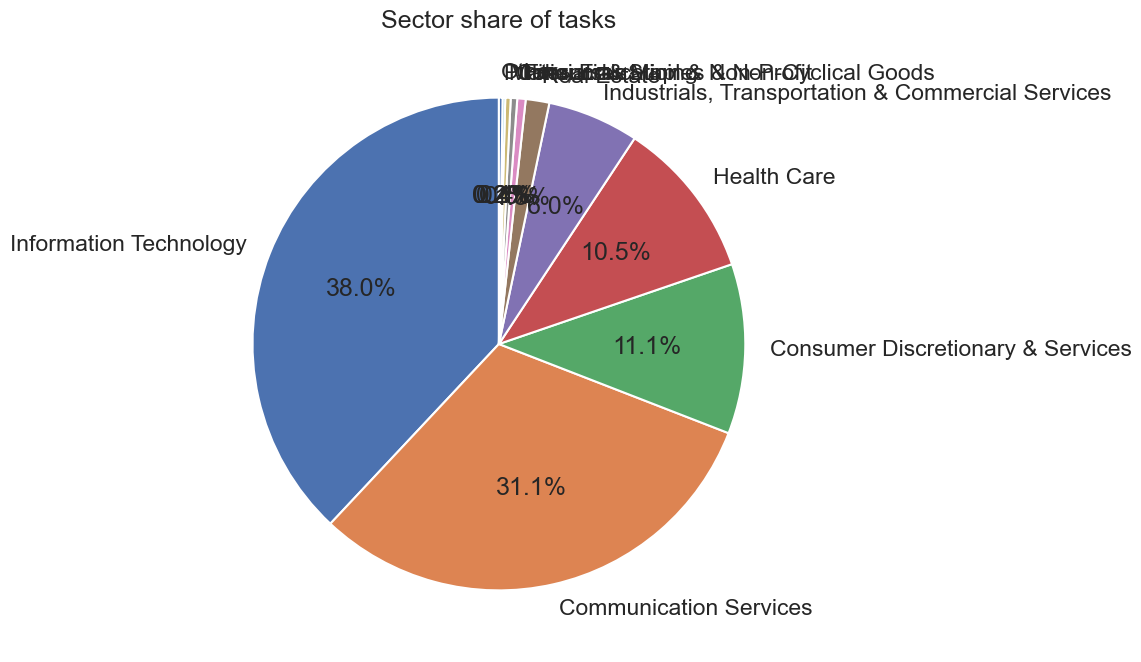

In [10]:
sector_dist = data["MANUFACTURER_SECTOR"].value_counts().rename_axis("sector").reset_index(name="task_count")
display(sector_dist)

pie_data = sector_dist.head(10).copy()
pie_data.loc[len(pie_data)] = {
    "sector": "Other",
    "task_count": sector_dist.iloc[10:]["task_count"].sum(),
}
plt.figure(figsize=(8, 8))
plt.pie(pie_data["task_count"], labels=pie_data["sector"], autopct="%1.1f%%", startangle=90)
plt.title("Sector share of tasks")
plt.show()